In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import time
import numpy as np
import random
import fractions

# **QC Coding Exam 2026**

Joaquín Gabriel Márquez Olguín

## Problem 1. Searching

a) Full Grover circuit using an oracle that labels the state |001>

In [2]:
n_bits = 3
query_register = list(range(n_bits))
aux = [n_bits]
all_wires = query_register + aux
dev = qml.device("default.qubit", wires=all_wires)

psi = [0,0,1]

def hadamard_transform(my_wires):
    """Apply the Hadamard transform on a given set of wires.

    Args:
        my_wires (list[int]): A list of wires on which the Hadamard transform will act.
    """
    for wire in my_wires:
        qml.Hadamard(wires=wire)

def oracle(combo):
    """Implement an oracle using a multi-controlled X gate.

    Args:
        combo (list): A list of bits representing the secret combination.
    """
    combo_str = "".join(str(j) for j in combo)

    # NOTE: MultiControlledX(wires, control_values) with:
    # wires = control wire(s) followed by a single target wire (the last entry of wires) where the operation acts on
    # control_values = the value(s) the control wire(s) should take
    
    qml.MultiControlledX(wires = all_wires, control_values = combo)

all_wires = query_register + aux
def diffusion():
    """Implement the diffusion operator using the Hadamard transform and
    multi-controlled X."""

    hadamard_transform(query_register)
    qml.MultiControlledX(wires = all_wires, control_values = [int(x) for x in np.zeros(len(query_register))])
    hadamard_transform(query_register)



@qml.qnode(dev)
def grover_circuit(combo):
    """Apply the MultiControlledX Grover operator and return probabilities on
    query register.

    Args:
        combo (list[int]): A list of bits representing the secret combination.

    Returns:
        array[float]: Measurement outcome probabilities.
    """
    # PREPARE QUERY AND AUXILIARY SYSTEM
    hadamard_transform(query_register)
    qml.PauliX(aux)
    qml.Hadamard(aux)
    
    # APPLY GROVER ITERATION
    oracle(combo)
    diffusion()
    return qml.probs(wires=query_register)


print('Prob. of measuring state |001>:', max(grover_circuit(psi)))


Prob. of measuring state |001>: 0.7812499999999989


b) Prob. of finding the correct solution given an increasing number of iterations of the circuit

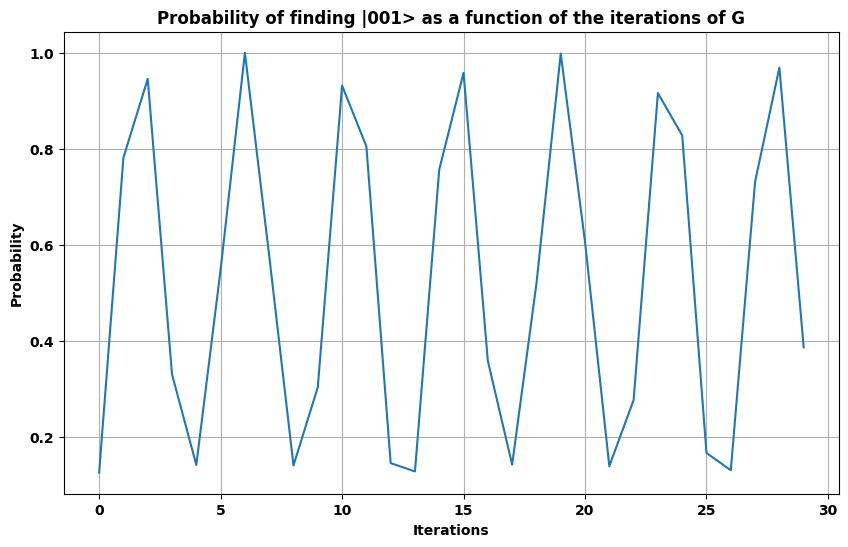

In [3]:
def grover_iter(combo, num_steps):
    """Run Grover search for a given secret combination and a number of iterations.

    Args:
        combo (list[int]): The secret combination, represented as a list of bits.
        num_steps (int): The number of Grover iterations to perform.

    Returns:
        array[float]: Probability for observing different outcomes.
    """
    n_bits = len(combo)
    query_register = list(range(n_bits))
    aux = [n_bits]
    all_wires = query_register + aux
    dev = qml.device("default.qubit", wires=all_wires)

    @qml.qnode(dev)
    def inner_circuit():
        # IMPLEMENT THE GROVER CIRCUIT

        # Prepare Qubits
        qml.PauliX(aux)
        hadamard_transform(all_wires)
        # Apply Grover algorithm
        for _ in range(num_steps):
            oracle(combo)
            diffusion()

        return qml.probs(wires=query_register)

    return inner_circuit()


iterations = []
max_iter = 30

for iter in range(max_iter):
    iterations.append(max(grover_iter(psi, iter)))

plt.figure(figsize=(10,6))
plt.plot(iterations)
plt.title('Probability of finding |001> as a function of the iterations of G')
plt.xlabel('Iterations')
plt.ylabel('Probability')
plt.grid(True)

c) Modify previous circuit to generate the state |++->

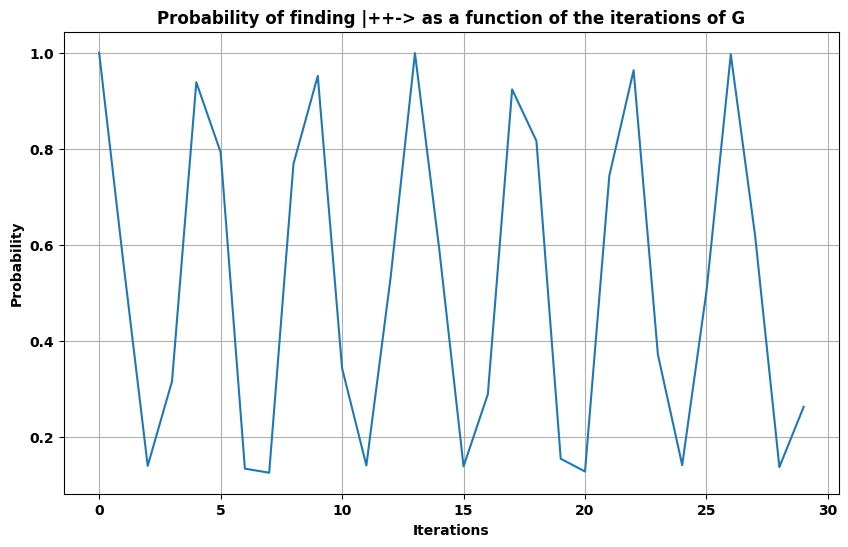

In [4]:
# we repeat the same process but at the end, we apply Hadamard gates to go from 0 -> + and 1 -> -

def grover_iter(combo, num_steps):
    """Run Grover search for a given secret combination and a number of iterations.

    Args:
        combo (list[int]): The secret combination, represented as a list of bits.
        num_steps (int): The number of Grover iterations to perform.

    Returns:
        array[float]: Probability for observing different outcomes.
    """
    n_bits = len(combo)
    query_register = list(range(n_bits))
    aux = [n_bits]
    all_wires = query_register + aux
    dev = qml.device("default.qubit", wires=all_wires)

    @qml.qnode(dev)
    def inner_circuit():
        # IMPLEMENT THE GROVER CIRCUIT

        # Prepare Qubits
        qml.PauliX(aux)
        hadamard_transform(all_wires)
        # Apply Grover algorithm
        for _ in range(num_steps):
            oracle(combo)
            diffusion()

        # now we apply Hadamard gates to go from |001> to |++->
        hadamard_transform(query_register)
        return qml.probs(wires=query_register)

    return inner_circuit()

iterations = []
max_iter = 30

for iter in range(max_iter):
    iterations.append(max(grover_iter(psi, iter)))

plt.figure(figsize=(10,6))
plt.plot(iterations)
plt.title('Probability of finding |++-> as a function of the iterations of G')
plt.xlabel('Iterations')
plt.ylabel('Probability')
plt.grid(True)

d) Build and execute the full Grover circuit using an oracle that labels the state |psi> = |001> + |011>

[0.  0.5 0.  0.5 0.  0.  0.  0. ]


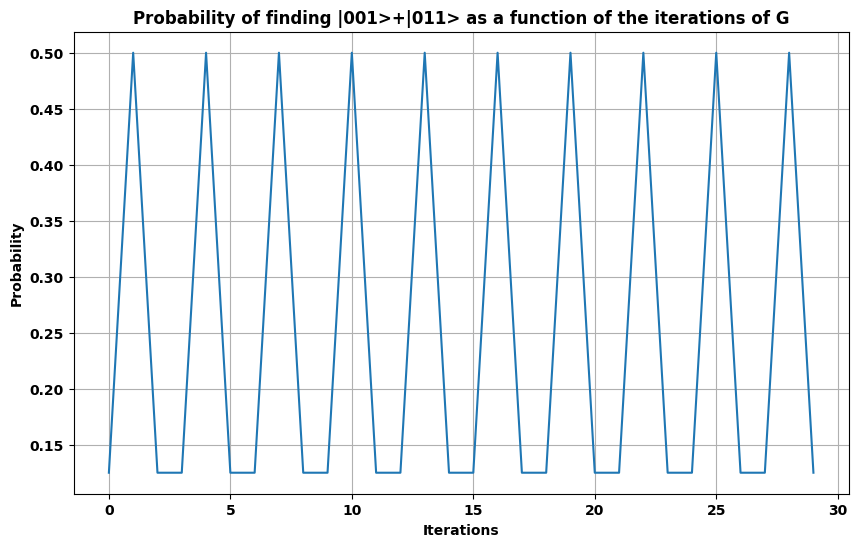

In [5]:
# we use the same code as before but modify the oracle to detect the two solutions instead of just one

def oracle_multi(combos):
    """Implement multi-solution oracle using sequence of multi-controlled X gates.

    Args:
        combos (list[list[int]]): A list of solutions.
    """
    for combo in combos:
        
        qml.MultiControlledX(all_wires, combo)

def grover_iter_multi(combos, num_steps):
    """Run Grover search for multiple secret combinations and a number
    of Grover steps.

    Args:
        combos (list[int]): The secret combination, represented as a list of bits.
        num_steps (int): The number of Grover iterations to perform.

    Returns:
        array[float]: Probability for observing different outcomes.
    """

    @qml.qnode(dev)
    def inner_circuit():
        qml.PauliX(aux)
        hadamard_transform(all_wires)

        for _ in range(num_steps):
            oracle_multi(combos)
            diffusion()
        return qml.probs(wires=query_register)

    return inner_circuit()


combos = [[0,0,1], [0,1,1]]
print(grover_iter_multi(combos, 1))
iterations = []
max_iter = 30

for iter in range(max_iter):
    iterations.append(max(grover_iter_multi(combos, iter)))

plt.figure(figsize=(10,6))
plt.plot(iterations)
plt.title('Probability of finding |001>+|011> as a function of the iterations of G')
plt.xlabel('Iterations')
plt.ylabel('Probability')
plt.grid(True)

## Problem 2. Real World factoring

In [6]:
# given functions:

def multi(x, y):
    z = 0
    while y>0:
        z=z+x
        y=y-1
    return z

def russian_peasant(x,y):
    z=0
    while y>0:
        if y%2 ==1: z = z+x
        x = x <<1
        y=y>>1
    return z

a) Compare the scaling of odd numbers as you increase the number of bits representing the numbers (identify easy and hard problems) using the function of the codebook. Make a plot as a function of the number of digits and fir a curve to the worst cases.

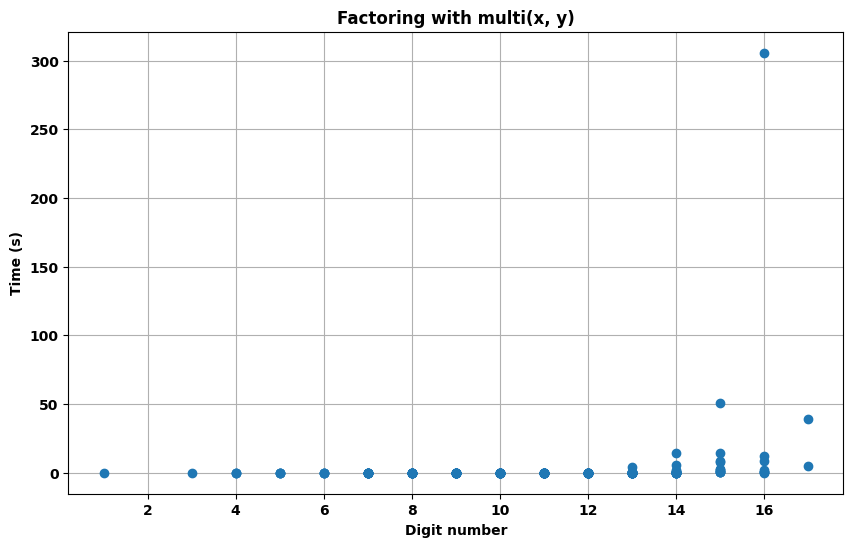

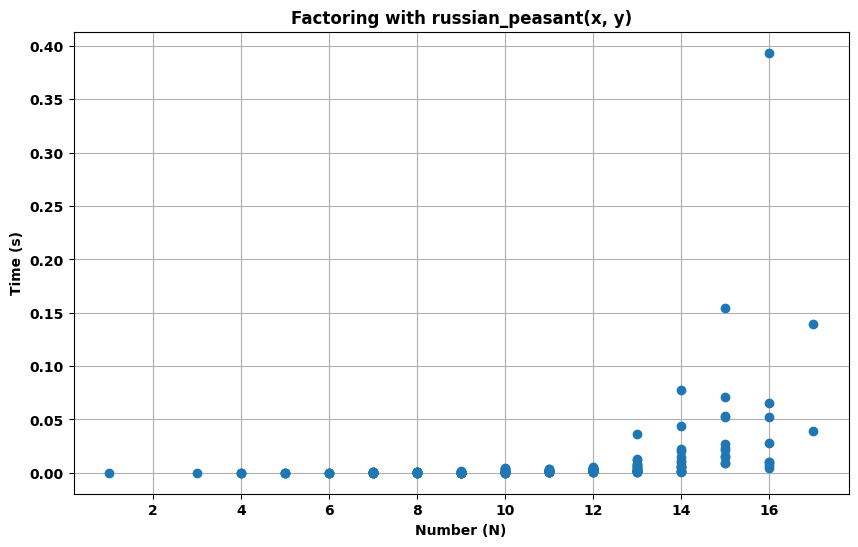

In [7]:
def nontrivial_square_root(m, type):
    """Return the first nontrivial square root modulo m.

    Args:
        m (int): modulus for which want to find the nontrivial square root
        type: 0 = multi and 1 = russian_peasant (for different types of multiplications)

    Returns:
        int: the first nontrivial square root of m
    """

    for i in range(2, m):
        #if i**2 % m == 1:
            #return i
        if type == 0:
            if multi(i, i) % m == 1:
                return i
        if type == 1:
            if russian_peasant(i, i) % m == 1:
                return i
    
    return -1

def factorization(N, type):
    """Return the factors of N.

    Args:
        N (int): number we want to factor.
        type: 0 = multi and 1 = russian_peasant (for different types of multiplications)

    Returns:
        array[int]: [p,q] factors of N.
    """
    nt_sqrt = nontrivial_square_root(N, type)

    p = np.gcd(nt_sqrt-1, N)
    q = np.gcd(nt_sqrt+1, N)
    return p, q

odd_num = []
for bits in range(3, 9): 
    for _ in range(3):  # to make it faster we take 3 samples per bit size
        num = random.getrandbits(bits)
        odd_num.append(2*num + 1) # we store odd numbers

numbers = []
times = []
bits = []


for i in range(len(odd_num)):
    for j in range(i,len(odd_num)):
        N=odd_num[i]*odd_num[j]
        numbers.append(N)
        bits.append(N.bit_length())
        start_time=time.time()
        factorization(N, type=0)
        end_time=time.time()
        times.append(end_time-start_time)

plt.figure(figsize=(10,6))
plt.plot(bits, times, 'o')
plt.xlabel('Digit number')
plt.ylabel('Time (s)')
plt.title('Factoring with multi(x, y)')
plt.grid(True)
plt.show()

numbers2=[]
times2=[]
bits2=[]
for i in range(len(odd_num)):
    for j in range(i,len(odd_num)):
        N2=odd_num[i]*odd_num[j]
        numbers2.append(N2)
        bits2.append(N2.bit_length())
        start_time2=time.time()
        factorization(N2, type=1)
        end_time2=time.time()
        times2.append(end_time2-start_time2)
        

plt.figure(figsize=(10,6))
plt.plot(bits2, times2, 'o')
plt.xlabel('Number (N)')
plt.ylabel('Time (s)')
plt.title('Factoring with russian_peasant(x, y)')
plt.grid(True)
plt.show()


b) We have access to a large number of Quantum Computers of the same size with equal capabilities. Comment how can you take advantage of this setup to speed up factoring?

*We could make use of quantum parallelism: using the quantum computers at the same time to try as many random and probabilistic combinations as possible and find the correct factors faster (quantum speed up)*

- If num of qubits is smaller than the required numbers to quantum factoring

*If the number of qubits is smaller than the required number, then we could use different computers to study a certain range of random probabilities so that we can explore the whole space of factors at the same type with different computers*

- if the num of qubits is larger than the required numberse to quantum factoring


*As explained at the begining, here we dont have any problem regarding the quantum factorization, so we use quantum parallelism with the different computers trying random and probabilistic combinations to get a faster quantum factorization(quantum speed up)*